In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [14]:
df = pd.read_csv("netflix_titles.csv")

In [15]:
print(df.shape)

(8807, 12)


In [16]:
print(df.dtypes)

show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object


In [17]:
print(df.isnull().sum())

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [18]:
print(df.duplicated().sum())

0


In [19]:
print(df['title'].nunique())

8807


In [20]:
print(df['type'].value_counts())

type
Movie      6131
TV Show    2676
Name: count, dtype: int64


In [21]:
print(df['type'].value_counts().idxmax())

Movie


In [22]:
print(df['release_year']. value_counts().sort_index())

release_year
1925       1
1942       2
1943       3
1944       3
1945       4
        ... 
2017    1032
2018    1147
2019    1030
2020     953
2021     592
Name: count, Length: 74, dtype: int64


In [23]:
print(df['release_year'].value_counts().idxmax())

2018


In [24]:
print(df['rating'].value_counts().idxmax())

TV-MA


In [25]:
print(df['country'].value_counts().idxmax())

United States


In [26]:
india_titles = df[df['country'].str.contains('India', na=False)]
print(india_titles.shape[0])

1046


In [27]:
print(df['country'].value_counts().head(10))

country
United States     2818
India              972
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64


In [28]:
print(df[df['type'] == 'TV Show']['country'].value_counts().head(10))

country
United States     760
United Kingdom    213
Japan             169
South Korea       158
India              79
Taiwan             68
Canada             59
France             49
Australia          48
Spain              48
Name: count, dtype: int64


In [29]:
print(df[df['type'] == 'Movie']['country'].value_counts().head(10))

country
United States     2058
India              893
United Kingdom     206
Canada             122
Spain               97
Egypt               92
Nigeria             86
Indonesia           77
Japan               76
Turkey              76
Name: count, dtype: int64


In [30]:
print(df['director'].value_counts().idxmax())

Rajiv Chilaka


In [31]:
director_counts = df['director'].value_counts()
print((director_counts == 1).sum())

3661


In [32]:
result = df.groupby('director')['type'].nunique()
print(result[result > 1])

director
Alessandro Angulo                    2
BB Sasore                            2
Billy Corben                         2
Brad Anderson                        2
Bunmi Ajakaiye                       2
Cosima Spender                       2
Dan Forrer                           2
Daniel Kontur                        2
David Ayer                           2
Eli Roth                             2
Estela Renner                        2
Jalil Lespert                        2
Jay Chandrasekhar                    2
Jerry Seinfeld                       2
Joe Berlinger                        2
John Dower                           2
Julien Leclercq                      2
Justin Webster                       2
Kemi Adetiba                         2
Kim Seong-hun                        2
Kobun Shizuno, Hiroyuki Seshita      2
Kyran Kelly                          2
Malik Nejer                          2
Manolo Caro                          2
Marcus Raboy                         2
Mark Tonderai   

In [33]:
movies = df[df['type'] == 'Movie']
print(movies['director'].value_counts().idxmax())

Rajiv Chilaka


In [34]:
tvshows = df[df['type'] == 'TV Show']
print(tvshows['director'].value_counts().idxmax())

Alastair Fothergill


In [35]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
print(df['date_added'].dt.year.value_counts().sort_index())

date_added
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      10
2014.0      23
2015.0      73
2016.0     418
2017.0    1164
2018.0    1625
2019.0    1999
2020.0    1878
2021.0    1498
Name: count, dtype: int64


In [36]:
print(df['date_added'].dt.month.value_counts().idxmax())

7.0


In [37]:
yearly = df['date_added'].dt.year.value_counts().sort_index()
growth = yearly.diff()
print(growth.idxmax())

2017.0


In [38]:
current_year = 2026
ages = current_year - df['release_year']
print(ages.describe())

count    8807.000000
mean       11.819802
std         8.819312
min         5.000000
25%         7.000000
50%         9.000000
75%        13.000000
max       101.000000
Name: release_year, dtype: float64


In [39]:
oldest = df[df['release_year'] == df['release_year'].min()]
print(oldest[['title', 'release_year']])

                                  title  release_year
4250  Pioneers: First Women Filmmakers*          1925


In [40]:
print(df['listed_in'].value_counts().idxmax())

Dramas, International Movies


In [41]:
print(df['listed_in'].value_counts().head(10))

listed_in
Dramas, International Movies                        362
Documentaries                                       359
Stand-Up Comedy                                     334
Comedies, Dramas, International Movies              274
Dramas, Independent Movies, International Movies    252
Kids' TV                                            220
Children & Family Movies                            215
Children & Family Movies, Comedies                  201
Documentaries, International Movies                 186
Dramas, International Movies, Romantic Movies       180
Name: count, dtype: int64


In [42]:
print(df[df['type'] == 'Movie']['listed_in'].value_counts().head(10))

listed_in
Dramas, International Movies                        362
Documentaries                                       359
Stand-Up Comedy                                     334
Comedies, Dramas, International Movies              274
Dramas, Independent Movies, International Movies    252
Children & Family Movies                            215
Children & Family Movies, Comedies                  201
Documentaries, International Movies                 186
Dramas, International Movies, Romantic Movies       180
Comedies, International Movies                      176
Name: count, dtype: int64


In [43]:
print(df[df['type'] == 'TV Show']['listed_in'].value_counts().head(10))

listed_in
Kids' TV                                                  220
International TV Shows, TV Dramas                         121
Crime TV Shows, International TV Shows, TV Dramas         110
Kids' TV, TV Comedies                                      99
Reality TV                                                 95
International TV Shows, Romantic TV Shows, TV Comedies     94
International TV Shows, Romantic TV Shows, TV Dramas       90
Anime Series, International TV Shows                       88
Docuseries                                                 85
TV Comedies                                                69
Name: count, dtype: int64


In [44]:
print(df['listed_in'].value_counts().head(10))

listed_in
Dramas, International Movies                        362
Documentaries                                       359
Stand-Up Comedy                                     334
Comedies, Dramas, International Movies              274
Dramas, Independent Movies, International Movies    252
Kids' TV                                            220
Children & Family Movies                            215
Children & Family Movies, Comedies                  201
Documentaries, International Movies                 186
Dramas, International Movies, Romantic Movies       180
Name: count, dtype: int64


In [45]:
print(df['rating'].value_counts())

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64


In [46]:
print(pd.crosstab(df['type'], df['rating']))

rating   66 min  74 min  84 min   G  NC-17  NR   PG  PG-13    R  TV-14  TV-G  \
type                                                                           
Movie         1       1       1  41      3  75  287    490  797   1427   126   
TV Show       0       0       0   0      0   5    0      0    2    733    94   

rating   TV-MA  TV-PG  TV-Y  TV-Y7  TV-Y7-FV  UR  
type                                              
Movie     2062    540   131    139         5   3  
TV Show   1145    323   176    195         1   0  


In [47]:
india = df[df['country'].str.contains('India', na=False)]
print(india['rating'].value_counts())

rating
TV-14       572
TV-MA       266
TV-PG       144
TV-Y7        17
PG-13        11
TV-G         10
PG            7
NR            7
TV-Y          6
R             5
TV-Y7-FV      1
Name: count, dtype: int64


In [48]:
tvma = df[df['rating'] == 'TV-MA']
print(tvma['country'].value_counts().idxmax())

United States


In [49]:
pg = df[df['rating'] == 'PG']
print(pg['release_year'].value_counts().head())

release_year
2018    31
2011    18
2014    15
2017    15
2020    15
Name: count, dtype: int64


In [50]:
movies = df[df['type'] == 'Movie'].copy()
movies['duration_int'] = movies['duration'].str.replace(' min', '').astype(float)
print(movies['duration_int'].mean())

99.57718668407311


In [51]:
longest = movies[movies['duration_int'] == movies['duration_int'].max()]
print(longest[['title', 'duration']])

                           title duration
4253  Black Mirror: Bandersnatch  312 min


In [52]:
shortest = movies[movies['duration_int'] == movies['duration_int'].min()]
print(shortest[['title', 'duration']])

       title duration
3777  Silent    3 min


In [53]:
tv = df[df['type'] == 'TV Show'].copy()
tv['season_count'] = tv['duration'].str.replace(' Seasons', '').str.replace(' Season', '').astype(float)
print(tv.loc[tv['season_count'].idxmax(), ['title', 'duration']])

title       Grey's Anatomy
duration        17 Seasons
Name: 548, dtype: object


In [54]:
print(tv['season_count'].mean())

1.764947683109118


In [55]:
print(df.isnull().sum())

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        98
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [56]:
missing_percent = (df.isnull().sum() / len(df)) * 100
print(missing_percent)

show_id          0.000000
type             0.000000
title            0.000000
director        29.908028
cast             9.367549
country          9.435676
date_added       1.112751
release_year     0.000000
rating           0.045418
duration         0.034064
listed_in        0.000000
description      0.000000
dtype: float64


In [58]:
df['director'] = df['director'].fillna('Unknown')
print(df['director'])

0       Kirsten Johnson
1               Unknown
2       Julien Leclercq
3               Unknown
4               Unknown
             ...       
8802      David Fincher
8803            Unknown
8804    Ruben Fleischer
8805       Peter Hewitt
8806        Mozez Singh
Name: director, Length: 8807, dtype: object


In [59]:
df = df.drop_duplicates()

In [60]:
df['country'] = df['country'].str.strip()

In [61]:
actors = df['cast'].dropna().str.split(', ')
all_actors = actors.explode()
print(all_actors.value_counts().head())

cast
Anupam Kher         43
Shah Rukh Khan      35
Julie Tejwani       33
Takahiro Sakurai    32
Naseeruddin Shah    32
Name: count, dtype: int64


In [62]:
from collections import Counter

words = ' '.join(df['description'].dropna()).lower().split()
print(Counter(words).most_common(20))

[('a', 11609), ('the', 8106), ('to', 6439), ('and', 6320), ('of', 5273), ('in', 4334), ('his', 3352), ('with', 2261), ('her', 2077), ('an', 1993), ('for', 1782), ('on', 1763), ('their', 1669), ('when', 1512), ('this', 1395), ('from', 1291), ('as', 1224), ('is', 1111), ('by', 1004), ('after', 993)]


In [63]:
print(df[df['title'].str.contains('Love', case=False, na=False)][['title']])

                               title
25              Love on the Spectrum
158          Love Don't Cost a Thing
159                   Love in a Puff
206        LSD: Love, Sex Aur Dhokha
227                      Really Love
...                              ...
8567  The Year of Happiness and Love
8575                 This Is My Love
8649           Two Lovers and a Bear
8721                   What Is Love?
8725            What's Up With Love?

[196 rows x 1 columns]


In [64]:
print(df[df['description'].str.contains('crime', case=False, na=False)][['title']])

                                    title
10    Vendetta: Truth, Lies and The Mafia
14        Crime Stories: India Detectives
84                   Omo Ghetto: the Saga
122                            In the Cut
133                               Chappie
...                                   ...
8510                          The Sniffer
8600                                Tobot
8755                    Women Behind Bars
8766                                  XXx
8802                               Zodiac

[222 rows x 1 columns]


In [65]:
df['desc_length'] = df['description'].str.len()
print(df[['title', 'desc_length']].sort_values(by='desc_length', ascending=False).head())

                             title  desc_length
4948                         Billu          248
4797               Namastey London          248
8156                    Teen Patti          246
7678  Opium and the Kung Fu Master          246
6221           Balto 2: Wolf Quest          245


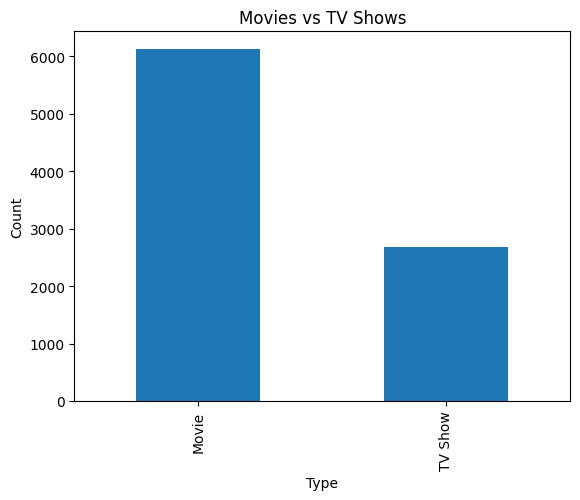

In [66]:
df['type'].value_counts().plot(kind='bar')
plt.title('Movies vs TV Shows')
plt.xlabel('Type')
plt.ylabel('Count')
plt.show()

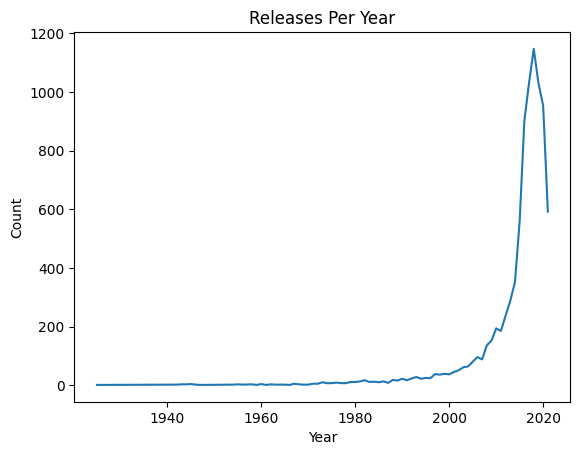

In [67]:
df['release_year'].value_counts().sort_index().plot()
plt.title('Releases Per Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()

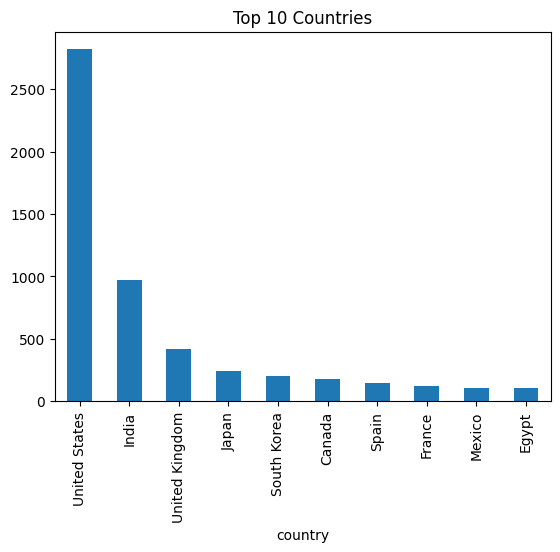

In [68]:
df['country'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Countries')
plt.show()

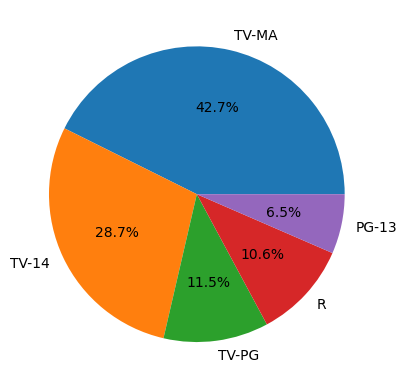

In [69]:
df['rating'].value_counts().head(5).plot(kind='pie', autopct='%1.1f%%')
plt.ylabel('')
plt.show()

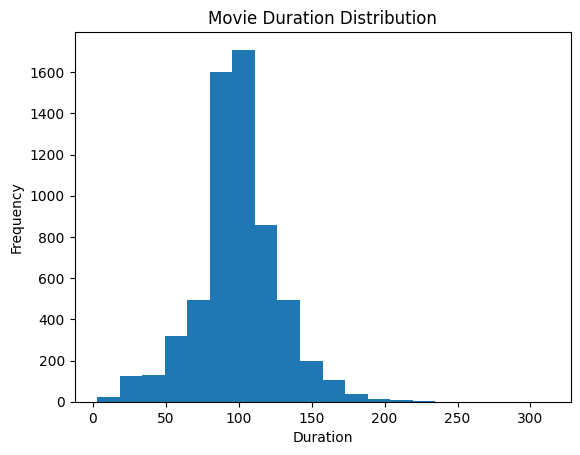

In [70]:
movies['duration_int'].plot(kind='hist', bins=20)
plt.xlabel('Duration')
plt.title('Movie Duration Distribution')
plt.show()

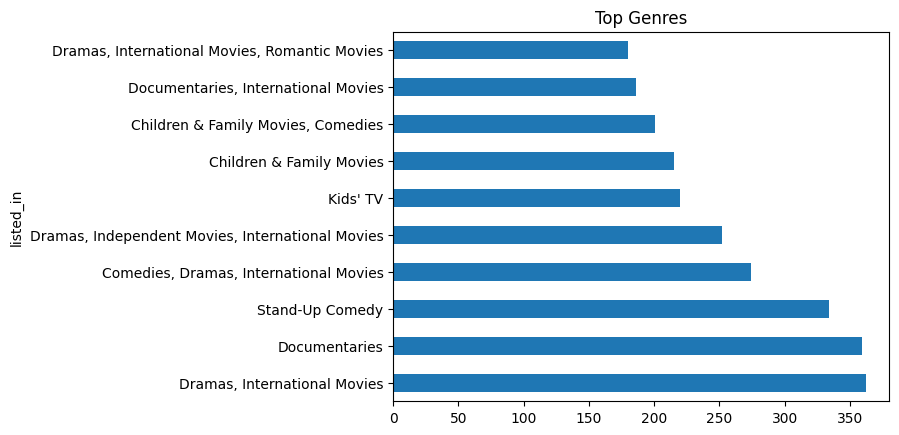

In [71]:
df['listed_in'].value_counts().head(10).plot(kind='barh')
plt.title('Top Genres')
plt.show()

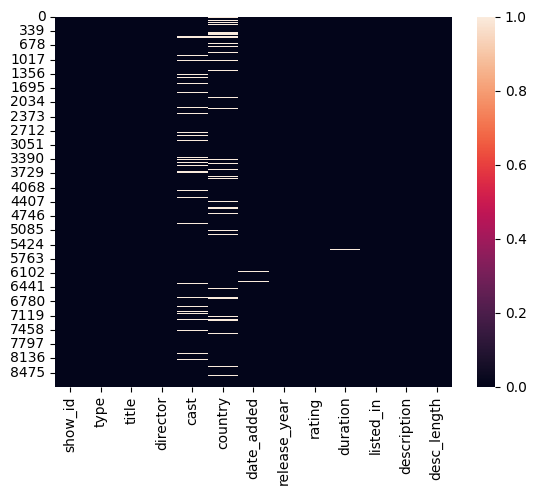

In [93]:
import seaborn as sns

sns.heatmap(df.isnull())
plt.show()

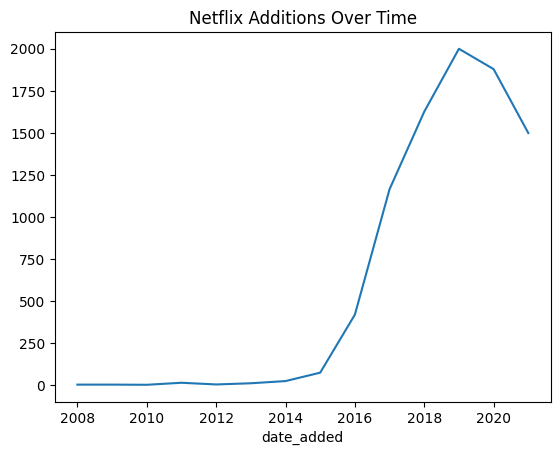

In [94]:
df['date_added'].dt.year.value_counts().sort_index().plot()
plt.title('Netflix Additions Over Time')
plt.show()

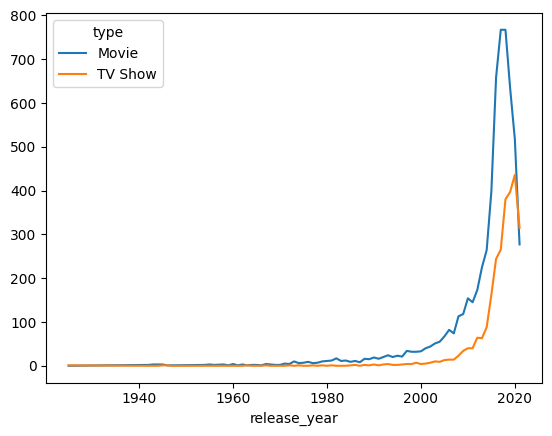

In [95]:
trend = pd.crosstab(df['release_year'], df['type'])
trend.plot()
plt.show()

In [96]:
recent = df[df['release_year'] > 2015]
print(recent['listed_in'].value_counts().head(10))

listed_in
Documentaries                                       286
Stand-Up Comedy                                     250
Dramas, International Movies                        216
Dramas, Independent Movies, International Movies    167
Kids' TV                                            157
Comedies, Dramas, International Movies              147
Documentaries, International Movies                 127
Children & Family Movies                            126
Dramas, International Movies, Romantic Movies       109
Comedies, International Movies                      105
Name: count, dtype: int64


In [97]:
mature = df[df['rating'] == 'TV-MA']
print(mature['release_year'].value_counts().sort_index())

release_year
1945      2
1963      1
1967      1
1970      1
1972      2
1973      1
1975      2
1976      1
1977      1
1978      2
1979      2
1981      1
1982      2
1983      4
1984      1
1985      3
1986      1
1987      1
1988      1
1989      2
1990      3
1991      5
1992      3
1993      4
1994      1
1995      1
1997      3
1998      7
1999      5
2000      1
2001      2
2002      7
2003      8
2004     10
2005      8
2006     17
2007     17
2008     25
2009     18
2010     42
2011     27
2012     54
2013     64
2014     79
2015    184
2016    341
2017    451
2018    549
2019    500
2020    469
2021    270
Name: count, dtype: int64


In [98]:
country_growth = df.groupby(['release_year', 'country']).size().unstack(fill_value=0)
print(country_growth)

country       , France, Algeria  , South Korea  Argentina  \
release_year                                                
1942                          0              0          0   
1943                          0              0          0   
1944                          0              0          0   
1945                          0              0          0   
1946                          0              0          0   
...                         ...            ...        ...   
2017                          0              0          4   
2018                          0              0         10   
2019                          0              0         11   
2020                          0              0         12   
2021                          0              1          2   

country       Argentina, Brazil, France, Poland, Germany, Denmark  \
release_year                                                        
1942                                                          0     

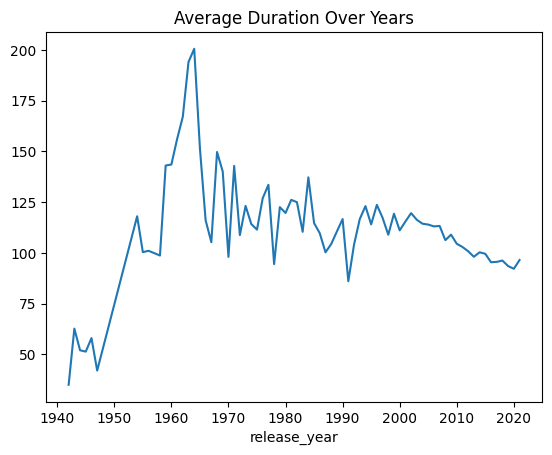

In [99]:
avg_duration = movies.groupby('release_year')['duration_int'].mean()
avg_duration.plot()
plt.title('Average Duration Over Years')
plt.show()

In [100]:
india = df[df['country'].str.contains('India', na=False)]
print(india['listed_in'].value_counts().head(10))

listed_in
Comedies, Dramas, International Movies              124
Dramas, International Movies                        123
Dramas, Independent Movies, International Movies    121
Dramas, International Movies, Romantic Movies        64
Action & Adventure, Dramas, International Movies     55
Dramas, International Movies, Thrillers              44
Comedies, International Movies, Romantic Movies      42
Dramas, International Movies, Music & Musicals       39
Comedies, International Movies, Music & Musicals     35
Comedies, Dramas, Independent Movies                 28
Name: count, dtype: int64


In [101]:
print(df.groupby('country')['listed_in'].value_counts().head(20))

country            listed_in                                                           
, France, Algeria  Dramas, Independent Movies, International Movies                        1
, South Korea      International TV Shows, TV Dramas                                       1
Argentina          Stand-Up Comedy                                                         8
                   Crime TV Shows, International TV Shows, Spanish-Language TV Shows       6
                   Dramas, International Movies                                            6
                   Documentaries, International Movies, Sports Movies                      4
                   Comedies, Cult Movies, International Movies                             2
                   Documentaries, International Movies                                     2
                   Dramas, Independent Movies, International Movies                        2
                   Dramas, International Movies, Thrillers                 

In [102]:
movies_df = df[df['type'] == 'Movie']
print(movies_df.head())

   show_id   type                             title  \
0       s1  Movie              Dick Johnson Is Dead   
6       s7  Movie  My Little Pony: A New Generation   
7       s8  Movie                           Sankofa   
9      s10  Movie                      The Starling   
12     s13  Movie                      Je Suis Karl   

                         director  \
0                 Kirsten Johnson   
6   Robert Cullen, José Luis Ucha   
7                    Haile Gerima   
9                  Theodore Melfi   
12            Christian Schwochow   

                                                 cast  \
0                                                 NaN   
6   Vanessa Hudgens, Kimiko Glenn, James Marsden, ...   
7   Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...   
9   Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...   
12  Luna Wedler, Jannis Niewöhner, Milan Peschel, ...   

                                              country date_added  \
0                                  

In [103]:
tv_df = df[df['type'] == 'TV Show']
print(tv_df.head())

  show_id     type                  title         director  \
1      s2  TV Show          Blood & Water          Unknown   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans          Unknown   
4      s5  TV Show           Kota Factory          Unknown   
5      s6  TV Show          Midnight Mass    Mike Flanagan   

                                                cast       country date_added  \
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...  South Africa 2021-09-24   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...           NaN 2021-09-24   
3                                                NaN           NaN 2021-09-24   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...         India 2021-09-24   
5  Kate Siegel, Zach Gilford, Hamish Linklater, H...           NaN 2021-09-24   

   release_year rating   duration  \
1          2021  TV-MA  2 Seasons   
2          2021  TV-MA   1 Season   
3          2021  TV-MA   1 Se

In [104]:
print(df.sort_values(by='release_year'))

     show_id     type                               title  \
4250   s4251  TV Show   Pioneers: First Women Filmmakers*   
7790   s7791    Movie                      Prelude to War   
8205   s8206    Movie                The Battle of Midway   
8739   s8740    Movie  Why We Fight: The Battle of Russia   
8763   s8764    Movie     WWII: Report from the Aleutians   
...      ...      ...                                 ...   
3         s4  TV Show               Jailbirds New Orleans   
2         s3  TV Show                           Ganglands   
18       s19    Movie                           Intrusion   
1         s2  TV Show                       Blood & Water   
68       s69    Movie                          Schumacher   

                                               director  \
4250                                            Unknown   
7790                                        Frank Capra   
8205                                          John Ford   
8739                        Fra

In [105]:
print(df.sort_values(by='release_year', ascending=False).head(20))

     show_id     type                                            title  \
1         s2  TV Show                                    Blood & Water   
2         s3  TV Show                                        Ganglands   
3         s4  TV Show                            Jailbirds New Orleans   
31       s32  TV Show                               Chicago Party Aunt   
30       s31    Movie                                  Ankahi Kahaniya   
25       s26  TV Show                             Love on the Spectrum   
23       s24    Movie     Go! Go! Cory Carson: Chrissy Takes the Wheel   
20       s21  TV Show  Monsters Inside: The 24 Faces of Billy Milligan   
19       s20  TV Show                                           Jaguar   
18       s19    Movie                                        Intrusion   
4         s5  TV Show                                     Kota Factory   
2920   s2921  TV Show                                    Love Is Blind   
49       s50  TV Show                 

In [106]:
print(df[df['release_year'] > 2018])

     show_id     type                        title             director  \
0         s1    Movie         Dick Johnson Is Dead      Kirsten Johnson   
1         s2  TV Show                Blood & Water              Unknown   
2         s3  TV Show                    Ganglands      Julien Leclercq   
3         s4  TV Show        Jailbirds New Orleans              Unknown   
4         s5  TV Show                 Kota Factory              Unknown   
...      ...      ...                          ...                  ...   
8516   s8517    Movie    The Spy Who Fell to Earth      Thomas Meadmore   
8631   s8632    Movie  Trixie Mattel: Moving Parts  Nicholas Zeig-Owens   
8718   s8719    Movie       Westside vs. the World        Michael Fahey   
8752   s8753    Movie                     Wish Man          Theo Davies   
8756   s8757    Movie                    Woodstock        Barak Goodman   

                                                   cast         country  \
0                       

In [107]:
print(df.groupby('country').size())

country
, France, Algeria                                       1
, South Korea                                           1
Argentina                                              56
Argentina, Brazil, France, Poland, Germany, Denmark     1
Argentina, Chile                                        2
                                                       ..
Venezuela                                               1
Venezuela, Colombia                                     1
Vietnam                                                 7
West Germany                                            1
Zimbabwe                                                1
Length: 748, dtype: int64


In [108]:
print(df.groupby(['release_year', 'type']).size())

release_year  type   
1925          TV Show      1
1942          Movie        2
1943          Movie        3
1944          Movie        3
1945          Movie        3
                        ... 
2019          TV Show    397
2020          Movie      517
              TV Show    436
2021          Movie      277
              TV Show    315
Length: 119, dtype: int64


In [109]:
print(movies.groupby('release_year')['duration_int'].mean())

release_year
1942    35.000000
1943    62.666667
1944    52.000000
1945    51.333333
1946    58.000000
          ...    
2017    95.535248
2018    96.185137
2019    93.466035
2020    92.141199
2021    96.444043
Name: duration_int, Length: 73, dtype: float64


In [110]:
print(df.groupby('listed_in').size())

listed_in
Action & Adventure                                              128
Action & Adventure, Anime Features                                1
Action & Adventure, Anime Features, Children & Family Movies      4
Action & Adventure, Anime Features, Classic Movies                2
Action & Adventure, Anime Features, Horror Movies                 1
                                                               ... 
TV Horror, TV Mysteries, Teen TV Shows                            1
TV Horror, Teen TV Shows                                          2
TV Sci-Fi & Fantasy, TV Thrillers                                 1
TV Shows                                                         16
Thrillers                                                        65
Length: 514, dtype: int64


In [111]:
genres = df.assign(listed_in=df['listed_in'].str.split(', ')).explode('listed_in')
print(genres.head())

  show_id     type                 title         director  \
0      s1    Movie  Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show         Blood & Water          Unknown   
1      s2  TV Show         Blood & Water          Unknown   
1      s2  TV Show         Blood & Water          Unknown   
2      s3  TV Show             Ganglands  Julien Leclercq   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   

  date_added  release_year rating   duration               listed_in  \
0 2021-09-25          2020  PG-13     90 min           Documentaries   
1 2021-09-24          2021  TV-MA  2 Seasons  International TV

In [127]:
movies['duration_number'] = pd.to_numeric(
    movies['duration'].str.extract(r'(\d+)')[0],
    errors='coerce'
)

print(movies[['title', 'duration_number']].head())

                               title  duration_number
0               Dick Johnson Is Dead             90.0
6   My Little Pony: A New Generation             91.0
7                            Sankofa            125.0
9                       The Starling            104.0
12                      Je Suis Karl            127.0


In [128]:
tv['season_number'] = tv['duration'].str.extract('(\d+)').astype(int)
print(tv[['title', 'season_number']].head())

                   title  season_number
1          Blood & Water              2
2              Ganglands              1
3  Jailbirds New Orleans              1
4           Kota Factory              2
5          Midnight Mass              1


In [129]:
df['date_added'] = pd.to_datetime(df['date_added'])
print(df['date_added'].head())

0   2021-09-25
1   2021-09-24
2   2021-09-24
3   2021-09-24
4   2021-09-24
Name: date_added, dtype: datetime64[ns]


In [130]:
print(df[df['title'].str.contains(r'\d', na=False)][['title']])

                                                  title
20      Monsters Inside: The 24 Faces of Billy Milligan
42                                               Jaws 2
43                                               Jaws 3
51    InuYasha the Movie 2: The Castle Beyond the Lo...
52    InuYasha the Movie 3: Swords of an Honorable R...
...                                                 ...
8626                      Tremors 6: A Cold Day in Hell
8713                                  Welcome 2 Karachi
8772                              Yamla Pagla Deewana 2
8778                                        Yes or No 2
8779                                      Yes or No 2.5

[483 rows x 1 columns]


In [131]:
print(df.select_dtypes(include='object').columns)

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'rating',
       'duration', 'listed_in', 'description'],
      dtype='object')


In [132]:
print(df.select_dtypes(include='object').columns)

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'rating',
       'duration', 'listed_in', 'description'],
      dtype='object')


In [133]:
text_columns = ['title', 'description', 'listed_in']
print(text_columns)

['title', 'description', 'listed_in']


In [134]:
features = ['type', 'country', 'release_year', 'listed_in', 'duration']
print(features)

['type', 'country', 'release_year', 'listed_in', 'duration']


In [135]:
print(df.columns)

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description',
       'desc_length'],
      dtype='object')


In [136]:
print(df['type'].value_counts())

type
Movie      6131
TV Show    2676
Name: count, dtype: int64


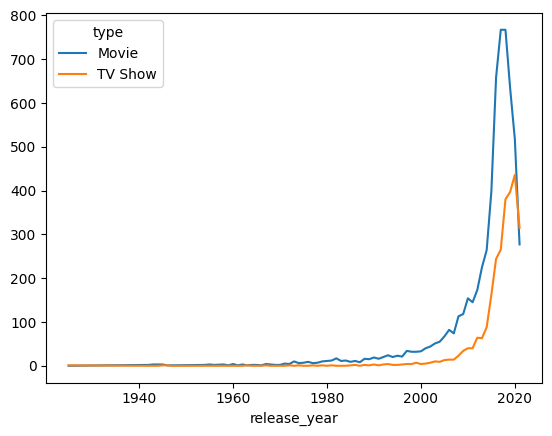

In [137]:
trend = pd.crosstab(df['release_year'], df['type'])
trend.plot()
plt.show()

In [138]:
print(df['country'].value_counts().tail(20))

country
United Kingdom, Canada, Japan                                     1
United Kingdom, United States, Czech Republic                     1
United Kingdom, China, United States                              1
United Kingdom, Brazil, Germany                                   1
United Kingdom, Namibia, South Africa, Zimbabwe, United States    1
Canada, United States, India, United Kingdom                      1
Switzerland, United Kingdom, United States                        1
United Kingdom, India, Sweden                                     1
United States, Brazil, India, Uganda, China                       1
Peru, United States, United Kingdom                               1
Germany, United States, United Kingdom, Canada                    1
Canada, India, Thailand, United States, United Arab Emirates      1
United States, East Germany, West Germany                         1
France, Netherlands, South Africa, Finland                        1
Egypt, Austria, United States           

In [139]:
print(df['rating'].value_counts())

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64


In [140]:
print(df['listed_in'].value_counts().head(20))

listed_in
Dramas, International Movies                         362
Documentaries                                        359
Stand-Up Comedy                                      334
Comedies, Dramas, International Movies               274
Dramas, Independent Movies, International Movies     252
Kids' TV                                             220
Children & Family Movies                             215
Children & Family Movies, Comedies                   201
Documentaries, International Movies                  186
Dramas, International Movies, Romantic Movies        180
Comedies, International Movies                       176
Comedies, International Movies, Romantic Movies      152
Dramas                                               138
Dramas, International Movies, Thrillers              134
Action & Adventure, Dramas, International Movies     132
Action & Adventure                                   128
International TV Shows, TV Dramas                    121
Comedies, Dramas, Ind